# Finding patterns with quantum computers

In [1]:
import numpy as np
from fractions import Fraction
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
backend = AerSimulator()

DIRECTIONS = {0: '→', 45: '↗', 90: '↑', 135: '↖', 180: '←', 225: '↙', 270: '↓', 315: '↘'}

def direction_symbol(angle_rad):
    angle_deg = np.degrees(angle_rad) % 360
    rounded = round(angle_deg / 45) * 45 % 360
    return DIRECTIONS.get(rounded, '?')

def angle_to_pi_str(angle_rad):
    """Convert a radian angle to a π-fraction string (e.g. π/2, -3π/4).
    Falls back to a decimal radian value if the angle is not a clean fraction of π."""
    if abs(angle_rad) < 1e-9:
        return '0'
    ratio = angle_rad / np.pi
    frac = Fraction(ratio).limit_denominator(64)
    if abs(float(frac) - ratio) > 1e-9:
        return f'{angle_rad:.4f}'
    num, den = frac.numerator, frac.denominator
    if den == 1:
        if num == 1:  return 'π'
        if num == -1: return '-π'
        return f'{num}π'
    if num == 1:  return f'π/{den}'
    if num == -1: return f'-π/{den}'
    return f'{num}π/{den}'

def show_statevector(algo, n):
    """Display the state vector, showing direction and magnitude for complex amplitudes."""
    v = Statevector(algo)
    data = v.data
    print(f"{'Row':>3}  {'State':>{n+2}}  Amplitude")
    print('-' * (n + 28))
    for i, amp in enumerate(data):
        state = f"|{format(i, f'0{n}b')}⟩"
        if abs(amp) < 0.001:
            val = '0'
        elif abs(amp.imag) < 0.001:
            val = f'{amp.real:+.3f}'
        else:
            mag = abs(amp)
            angle_rad = np.angle(amp)
            sym = direction_symbol(angle_rad)
            val = f'magnitude {mag:.3f}, direction {angle_to_pi_str(angle_rad)}  {sym}'
        print(f' {i:2d}  {state:>{n+2}}  {val}')

Generating random numbers, computing non-uniform probability distributions, and running multiple digital operations in parallel are all useful demonstrations of what quantum computers can do. Grover's algorithm took this further: it showed how to find a specific answer quadratically faster than a classical computer by amplifying the row corresponding to the right answer.

There is a different class of problem where the goal is not to find a specific answer, but to find a *hidden pattern*. You do not know what you are looking for, but you know the answer repeats with some period. This notebook introduces the **Quantum Fourier Transform (QFT)** — the quantum operation that finds hidden periods in a state vector. On its own it is a tool, not a complete algorithm, but it is the key ingredient in Shor's algorithm, which can factor large numbers exponentially faster than any known digital approach. Factoring large numbers underlies most modern public-key encryption, which is why quantum computing is taken seriously as a long-term cryptographic concern.

Before getting to what makes the *quantum* Fourier transform different, it is worth understanding what the Fourier transform already does on a digital computer.

### The classical Fourier transform

Finding a hidden period in a list of numbers is not a new problem. Digital computers solve it using the **Fourier transform**, which takes a list of values and answers the question: *what repeating patterns are hidden in these numbers, and how strongly does each one appear?*

A concrete example: suppose you record a sound. That recording is a list of thousands of numbers — the air pressure at each moment in time. The Fourier transform converts this list into a different list, where each row represents a frequency (a repeating pattern of a specific speed), and the value in that row tells you how much of that frequency is present. A pure musical note produces one large row and mostly zeros everywhere else. A chord produces several large rows. This is exactly what audio software does when it draws a frequency spectrum.

The same idea applies to any periodic data, not just sound. If you had a function that repeated every 7 steps, the Fourier transform of that function would produce a spike at the row corresponding to "repeats every 7."

A digital computer can perform this calculation efficiently enough to run in real time on a phone. For most practical pattern-finding tasks, the digital Fourier transform is the right tool.

**The QFT is different in two ways:**

First, it operates on a *quantum* state vector. The values in each row are probability amplitudes, not ordinary numbers, and the QFT uses the directional amplitude rules introduced in the next section to concentrate amplitude toward the rows that correspond to real frequencies while the rest cancel out. The state vector holds many values packed into a small number of qubits — the same 8-row state vector used below lives in just 3 qubits.

Second, the QFT is dramatically faster than any known digital approach for large inputs. The speedup is not incremental — for the sizes relevant to cryptography, no digital computer could finish in any practical amount of time, while the quantum version completes quickly. This exponential speedup is what makes Shor's algorithm possible.

The catch: you cannot simply read out the transformed state vector. Measurement collapses it to a single row. This means the QFT is only useful when the input state has a strong enough concentration at a few rows that those rows show up reliably when measured. A periodic input is exactly the case where that happens — and preparing such a periodic quantum state is the hard part of Shor's algorithm.

To make directional amplitudes work, a small extension to the amplitude model is needed first.

### Extending the amplitude model

So far in these notebooks, the numbers in the quantum state vector (also known as probability amplitudes) have been ordinary numbers: positive, negative, or zero. Squaring them gives a probability. This was enough to explain H, CX, CCX, Z, CCZ, and the other operations we have seen.

To understand the QFT, one extension is needed: **probability amplitudes can also have a direction**, like the hand of a clock. A clock hand has two properties — how long it is (the magnitude) and which way it points (the angle).

This might seem to change everything about how probabilities work. It does not. Probability still depends only on the magnitude — the length of the clock hand — not on which direction it points. Squaring the magnitude gives the probability exactly as before. The direction only matters during computation, when amplitudes from different rows combine.

The rules for directional amplitudes are simple:

| Situation | What happens |
| :- | :- |
| Probability of a row | magnitude² — direction is ignored at measurement |
| Two amplitudes pointing the **same direction** | Their magnitudes add — constructive interference |
| Two amplitudes pointing **opposite directions** | They cancel — destructive interference |
| Amplitudes spread **evenly around the clock** | They all cancel |
| Multiplying two amplitudes | Magnitudes multiply, angles add |

The QFT uses directions that are equally spaced around the clock. For a system with 8 rows (3 qubits), there are 8 equally spaced directions: 0, π/4, π/2, 3π/4, π, -3π/4, -π/2, and -π/4. An important property of equally spaced directions: if you sum contributions pointing in each of these equally-spaced directions, they always cancel.

### P operation

The P operation ("phase rotation") is a new operation that makes use of directional amplitudes. It works on a single qubit and rotates the direction of the amplitude in the $\rvert1\rangle$ row by a specified angle, leaving the $\rvert0\rangle$ row unchanged.

If the amplitude in the $\rvert1\rangle$ row was pointing right (angle 0), P(π/2) rotates it to point up (π/2). P(π) would rotate it to point left, which is equivalent to flipping the sign — and indeed P(π) is the same as the Z operation from the previous notebook.

Here is P in action. First, H creates a uniform probability distribution with both rows pointing right at the same magnitude. Then P(π/2) rotates the $\rvert1\rangle$ row by π/2 to point upward.

| Row | Start | After H | After P(π/2) |
| :- | :- | :- | :- |
| $\rvert0\rangle$ | +1.000 | +0.707 | +0.707 |
| $\rvert1\rangle$ | 0 | +0.707 | magnitude 0.707, direction π/2  ↑ |

H spreads the amplitude evenly across both rows, both pointing right. P(π/2) then rotates only the $\rvert1\rangle$ row — the magnitude is unchanged, so the probability stays at 50%, but the direction moves from 0 to π/2.

In [2]:
algo1 = QuantumCircuit(1)
algo1.h(0)
print('After H:')
show_statevector(algo1, 1)

print()

algo1.p(np.pi / 2, 0)   # P(π/2) — rotate |1⟩ row by π/2
print('After P(π/2):')
show_statevector(algo1, 1)

After H:
Row  State  Amplitude
-----------------------------
  0  |0⟩  +0.707
  1  |1⟩  +0.707

After P(π/2):
Row  State  Amplitude
-----------------------------
  0  |0⟩  +0.707
  1  |1⟩  magnitude 0.707, direction π/2  ↑


The $\rvert0\rangle$ row is unchanged. The $\rvert1\rangle$ row now has its amplitude pointing at π/2 — up, rather than right. The magnitude is still $\frac{1}{\sqrt{2}}$, so the probability of measuring $\rvert1\rangle$ is still 50%. The direction change has no effect on any measurement taken right now, but it will matter when this amplitude is later combined with others.

### CP operation

The CP operation ("constrained phase rotation") is the conditional version of P. It applies P to the target qubit only when the control qubit is $\rvert1\rangle$. This is the same pattern we have seen with CX and CCX — a more powerful operation gets a "constrained" variant that applies it selectively.

CP is used extensively inside the QFT to set up the specific pattern of clock directions that makes interference work.

### H is already a pattern finder

Before introducing the full QFT, it is worth noticing that the H operation — first seen in notebook 1 — is already a pattern finder for the simplest possible case: two rows.

If both rows have the same sign (a uniform pattern), applying H concentrates everything into the $\rvert0\rangle$ row. If the rows have opposite signs (an alternating pattern), H concentrates everything into the $\rvert1\rangle$ row. The row that lights up tells you the period of the pattern.

Let's see this directly. We will use H to create specific patterns, then apply H again and observe which row the amplitude lands in.

In [3]:
# Uniform pattern: both rows have the same value.
# H creates it, then H again detects it — collapses to row 0.
algo2 = QuantumCircuit(1)
algo2.h(0)  # creates uniform probability distribution
algo2.h(0)  # H detects the uniform pattern
print('Uniform pattern → H detects frequency 0 (no repeating pattern):')
show_statevector(algo2, 1)

print()

# Alternating pattern: rows have opposite signs.
# X followed by H creates (|0> - |1>)/√2. H then detects it — collapses to row 1.
algo3 = QuantumCircuit(1)
algo3.x(0)   # |1>
algo3.h(0)   # creates (|0> - |1>)/√2: an alternating pattern
algo3.h(0)   # H detects the alternating pattern
print('Alternating pattern → H detects frequency 1 (period 2):')
show_statevector(algo3, 1)

Uniform pattern → H detects frequency 0 (no repeating pattern):
Row  State  Amplitude
-----------------------------
  0  |0⟩  +1.000
  1  |1⟩  0

Alternating pattern → H detects frequency 1 (period 2):
Row  State  Amplitude
-----------------------------
  0  |0⟩  0
  1  |1⟩  +1.000


H distinguishes two patterns in a 2-row state vector. Row 0 lighting up means "no period — uniform". Row 1 lighting up means "the values alternate — period 2". This is pattern detection in its simplest form.

The QFT generalises this to 8, 16, 32, or any power-of-2 number of rows, detecting patterns of any period using H and CP together.

### The Quantum Fourier Transform

The QFT transforms a state vector row by row. For each output row, it computes a sum of contributions — one from every input row. The direction of each contribution is determined by both the input row number and the output row number: contributions involving lower-numbered rows stay close to direction 0, while contributions involving higher-numbered rows are rotated further around the clock. When all the contributions for an output row point in the same direction, they add up to a large amplitude; when they spread evenly around the clock, they cancel to zero.

H and CP together carry out this calculation across all qubits at once. The CP operations use angles of $\frac{\pi}{2}$, $\frac{\pi}{4}$, $\frac{\pi}{8}$, and so on — quarter turns, eighth turns, sixteenth turns — to set the precise clock directions that make the interference work. A concrete example of which contributions survive and which cancel follows after the QFT is run.

The function below implements the QFT on a list of qubits.

In [4]:
def add_qft(algo, qubits):
    """Apply the Quantum Fourier Transform to the specified qubits."""
    n = len(qubits)
    for i in range(n - 1, -1, -1):
        algo.h(qubits[i])
        for j in range(i - 1, -1, -1):
            angle = np.pi / 2 ** (i - j)
            algo.cp(angle, qubits[j], qubits[i])
    for i in range(n // 2):
        algo.swap(qubits[i], qubits[n - 1 - i])

### A periodic state

To see the QFT find a period, we need a state vector with a repeating pattern. We will use 3 qubits (8 rows) and create a state where rows 0, 2, 4, and 6 have non-zero amplitude, and rows 1, 3, 5, 7 are all zero. The non-zero rows are separated by a gap of 2, so this is a **period-2** pattern.

This state can be prepared by applying H to two of the three qubits while the third stays at $\rvert0\rangle$, which creates a uniform probability distribution over the 4 rows where that qubit is 0.

| Qubits | Initial state vector | H(1) | H(2) |
| :- | :- | :- | :- |
| $\rvert000\rangle$ ($\rvert0\rangle$) | $1.0$ | $\frac{1}{\sqrt{2}}$ | $\frac{1}{2}$ |
| $\rvert001\rangle$ ($\rvert1\rangle$) | $0.0$ | $\frac{1}{\sqrt{2}}$ | $0.0$ |
| $\rvert010\rangle$ ($\rvert2\rangle$) | $0.0$ | $0.0$ | $\frac{1}{2}$ |
| $\rvert011\rangle$ ($\rvert3\rangle$) | $0.0$ | $0.0$ | $0.0$ |
| $\rvert100\rangle$ ($\rvert4\rangle$) | $0.0$ | $0.0$ | $\frac{1}{2}$ |
| $\rvert101\rangle$ ($\rvert5\rangle$) | $0.0$ | $0.0$ | $0.0$ |
| $\rvert110\rangle$ ($\rvert6\rangle$) | $0.0$ | $0.0$ | $\frac{1}{2}$ |
| $\rvert111\rangle$ ($\rvert7\rangle$) | $0.0$ | $0.0$ | $0.0$ |

In [5]:
# Prepare a period-2 state: non-zero at rows 0, 2, 4, 6
algo4 = QuantumCircuit(3)
algo4.h(1)
algo4.h(2)

print('Period-2 state (non-zero at rows 0, 2, 4, 6):')
show_statevector(algo4, 3)

Period-2 state (non-zero at rows 0, 2, 4, 6):
Row  State  Amplitude
-------------------------------
  0  |000⟩  +0.500
  1  |001⟩  0
  2  |010⟩  +0.500
  3  |011⟩  0
  4  |100⟩  +0.500
  5  |101⟩  0
  6  |110⟩  +0.500
  7  |111⟩  0


Now we apply the QFT to this periodic state and inspect what comes out.

In [6]:
add_qft(algo4, [0, 1, 2])

print('After QFT:')
show_statevector(algo4, 3)

After QFT:
Row  State  Amplitude
-------------------------------
  0  |000⟩  +0.707
  1  |001⟩  0
  2  |010⟩  0
  3  |011⟩  0
  4  |100⟩  +0.707
  5  |101⟩  0
  6  |110⟩  0
  7  |111⟩  0


After the QFT, only rows 0 and 4 have non-zero amplitude. Every other row has cancelled out.

### Why only rows 0 and 4 survive

The QFT computes a sum for each output row, collecting one contribution from each non-zero input row. For our period-2 input, there are four contributing input rows (0, 2, 4, 6), each with magnitude $\frac{1}{2}$. Each contribution has a direction determined by both the input row number and the output row number — the same multiplication rule from the extended amplitude model: multiply magnitudes, add angles.

The 8-row system uses 8 equally spaced clock directions, one every π/4:

| Angle | Symbol |
| :- | :- |
| 0 | → |
| π/4 | ↗ |
| π/2 | ↑ |
| 3π/4 | ↖ |
| π | ← |
| -3π/4 | ↙ |
| -π/2 | ↓ |
| -π/4 | ↘ |

Here are the clock directions of each contribution, for every output row:

| Output row | From row 0 | From row 2 | From row 4 | From row 6 | Result |
| :- | :- | :- | :- | :- | :- |
| 0 | → (0) | → (0) | → (0) | → (0) | **Add up** |
| 1 | → (0) | ↑ (π/2) | ← (π) | ↓ (-π/2) | Cancel |
| 2 | → (0) | ← (π) | → (0) | ← (π) | Cancel |
| 3 | → (0) | ↓ (-π/2) | ← (π) | ↑ (π/2) | Cancel |
| 4 | → (0) | → (0) | → (0) | → (0) | **Add up** |
| 5 | → (0) | ↑ (π/2) | ← (π) | ↓ (-π/2) | Cancel |
| 6 | → (0) | ← (π) | → (0) | ← (π) | Cancel |
| 7 | → (0) | ↓ (-π/2) | ← (π) | ↑ (π/2) | Cancel |

Rows 0 and 4 receive contributions that all point in the same direction (right), so they add up to a large amplitude. Every other row receives contributions spread across different clock directions, so they cancel out.

Row 4 is the key result. It tells us the **frequency**: the period-2 pattern completes 4 cycles across the 8-row state vector. The period is recovered from the frequency:

$$\text{period} = \frac{N}{\text{frequency}} = \frac{8}{4} = 2$$

Row 0 (frequency 0) always appears for any periodic input — it is the contribution from the overall non-zero amplitude, not a pattern frequency.

Measurement results: {'100': 478, '000': 522}


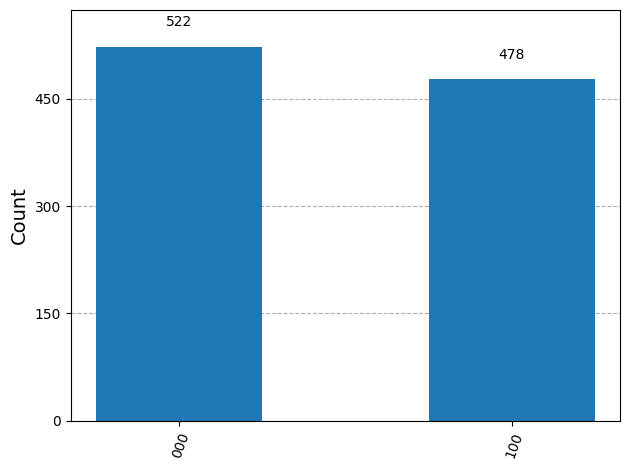

In [8]:
# Measure and run
algo5 = QuantumCircuit(3)
algo5.h(1)
algo5.h(2)
add_qft(algo5, [0, 1, 2])
algo5.measure_all()

result = backend.run(transpile(algo5, backend), shots=1000).result()
counts = result.get_counts()
print('Measurement results:', counts)
plot_histogram(counts)

The histogram shows exactly two outcomes, each with roughly 50% probability. In Qiskit's output, bitstrings are written with qubit 2 on the left and qubit 0 on the right:

- **000** — this is row 0 (frequency 0, the baseline contribution)
- **100** — this is row 4 (frequency 4, indicating period 2)

Every other row has zero probability, confirming that the interference cancelled them exactly.

To extract the period from a measurement of row $k$:

$$\text{period} = \frac{N}{k} = \frac{8}{4} = 2$$

A classical computer could verify this in one step, but finding the period in the first place — without the QFT — would require checking each row of a large periodic function one at a time.

### What comes next

The QFT efficiently extracts a period from a state vector that encodes one. On its own, this is a useful tool, but the hard part of Shor's algorithm is constructing the periodic state in the first place. In Shor's algorithm, a quantum algorithm computes a modular exponentiation function across all inputs simultaneously, creating a state vector whose period is directly related to the factors of the number being factored. The QFT is then applied to reveal that period, and a short classical calculation recovers the factors.

That is the subject of the next notebook.

### In conclusion

This notebook extended the probability amplitude model to include directional amplitudes (clock hands), introduced the P and CP operations that rotate those directions, and showed how the Quantum Fourier Transform uses constructive and destructive interference to reveal the period hidden in a state vector. Here is the complete set of operations across all five notebooks:

| Operation | Short-hand description | Specified by | Detailed description |
| :- | :- | :- | :- |
| H | "half" | 1 qubit | For all pairs of rows that differ only by the value of a specific qubit, replace the first row value with the *sum* of the pair divided by $\sqrt{2}$, and the second with the *difference* divided by $\sqrt{2}$. |
| CX | "constrained swap" | 2 qubits | For all pairs of rows where the first qubit is $\rvert1\rangle$ and the rows differ only in the second qubit, swap the values in the pair. |
| RY | "relative swap" | 1 angle, 1 qubit | For all pairs of rows that differ only in one qubit, partially move amplitude between them by the specified angle, introducing a sign flip on one direction. |
| X | "swap" | 1 qubit | For all pairs of rows that differ only by the value of a specific qubit, swap the values in the pair. |
| CCX | "doubly constrained swap" | 3 qubits | For all pairs of rows where both the first and second qubits are $\rvert1\rangle$ and the rows differ only in the third qubit, swap the values in the pair. |
| Z | "flip" | 1 qubit | For all pairs of rows that differ only in a specific qubit, flip the sign on the second row of each pair. |
| CCZ | "doubly constrained flip" | 3 qubits | For all pairs of rows where both the first and second qubits are $\rvert1\rangle$ and the rows differ only in the third qubit, flip the sign on the second row. |
| P | "phase rotation" | 1 angle, 1 qubit | Rotates the direction of the amplitude in the $\rvert1\rangle$ row by the specified angle, leaving the $\rvert0\rangle$ row unchanged. |
| CP | "constrained phase rotation" | 1 angle, 2 qubits | Applies P to the target qubit only when the control qubit is $\rvert1\rangle$. |